# Profile: institutional

The third profile is an **institutional mandate** — a large, benchmarked book hemmed in by rules.
Where the [retail profile](01_Profile_Retail_Daily.md) optimised for cost and the
[desk profile](02_Profile_Desk_Monthly.md) optimised for a view, this one optimises *within
constraints*: concentration limits, sector caps, and a tracking-error budget against a benchmark.
The size makes exact execution worthwhile.

The reasoning, following the [strategy decision framework](../../user_guide/06_Choosing_a_Strategy.md):

  - **The mandate is the boss** — per-name caps, sector limits, and a benchmark tracking-error
    ceiling are hard requirements, exactly what the `JuMPOptimiser` constraint keywords
    express.
  - **Benchmarked** — this is enhanced indexing: minimise risk but stay within a tracking-error
    budget of the benchmark (see [Turnover and Tracking](../4_constraints_costs/04_Turnover_and_Tracking.md)).
  - **Large and precise** — a big book justifies an exact `DiscreteAllocation`.

> **When to reach for this**
>
> This is the template for a constrained, benchmarked institutional book: stack the mandate's
> rules as `JuMPOptimiser` keywords, bound tracking error to the benchmark, and allocate exactly.
> The constraints, not the prior, are doing most of the work.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, HiGHS, StatsPlots,
      GraphRecipes

resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. Data, benchmark, and groups

The benchmark is an equal-weight book; the sectors are named so the mandate's sector caps can
reference them.

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)
N = length(rd.nx)

prices = vec(values(X)[end, :])
benchmark = fill(1 / N, N)

sets = AssetSets(; dict = Dict("nx" => rd.nx,
                               "tech" => ["AAPL", "AMD", "MSFT"],
                               "energy" => ["CVX", "XOM", "RRC"],
                               "healthcare" => ["JNJ", "LLY", "MRK", "PFE", "UNH"]))

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

Solver
         name ┼ Symbol: :clarabel
       solver ┼ UnionAll: Clarabel.MOIwrapper.Optimizer
     settings ┼ Dict{String, Bool}: Dict{String, Bool}("verbose" => 0)
    check_sol ┼ @NamedTuple{allow_local::Bool, allow_almost::Bool}: (allow_local = true, allow_almost = true)
  add_bridges ┴ Bool: true


## 2. The constrained optimisation

Minimum risk, subject to the full mandate: a 10% per-name cap, an energy sector limit, and a
tracking-error budget against the benchmark. Every rule is a keyword on the `JuMPOptimiser`.

In [3]:
institutional = optimise(MeanRisk(; obj = MinimumRisk(),
                                  opt = JuMPOptimiser(; pe = pr, slv = slv, sets = sets,
                                                      wb = WeightBounds(; lb = 0.0, ub = 0.10),
                                                      lcse = LinearConstraintEstimator(;
                                                                                       val = ["energy <= 0.2"]),
                                                      tr = TrackingError(;
                                                                         tr = WeightsTracking(; w = benchmark),
                                                                         err = 0.005))))

sector_weight(w, g) = sum(w[i] for i in eachindex(w) if rd.nx[i] in sets.dict[g])
pretty_table(DataFrame("Sector" => ["tech", "energy", "healthcare"],
                       "Benchmark" => [sector_weight(benchmark, g) for g in ["tech", "energy", "healthcare"]],
                       "Mandate book" => [sector_weight(institutional.w, g) for g in ["tech", "energy", "healthcare"]]);
             formatters = [resfmt],
             title = "Institutional book — capped, energy-limited, benchmark-tracking")

Institutional book — capped, energy-limited, benchmark-tracking
┌────────────┬───────────┬──────────────┐
│     Sector │ Benchmark │ Mandate book │
│     String │   Float64 │      Float64 │
├────────────┼───────────┼──────────────┤
│       tech │    15.0 % │      2.818 % │
│     energy │    15.0 % │     15.002 % │
│ healthcare │    25.0 % │     28.487 % │
└────────────┴───────────┴──────────────┘


The book respects every rule: no name above 10%, energy under its cap, and the whole portfolio
stays within the tracking-error budget of the benchmark — diversified by construction rather than
by a single objective.

## 3. Exact finite allocation

On a \$10,000,000 book, `DiscreteAllocation` with a MIP solver
([HiGHS](https://github.com/jump-dev/HiGHS.jl)) turns the target into whole shares with negligible
residual cash.

In [4]:
mip_slv = Solver(; name = :highs, solver = HiGHS.Optimizer,
                 settings = Dict("log_to_console" => false))
alloc = optimise(DiscreteAllocation(; slv = mip_slv), institutional.w, prices, 10_000_000.0)

invested = sum(alloc.shares .* prices)
pretty_table(DataFrame("Asset" => rd.nx, "Target" => institutional.w,
                       "Shares" => round.(Int, alloc.shares), "Realised" => alloc.w);
             formatters = [resfmt],
             title = "\$10,000,000 allocated — invested \$$(round(Int, invested)), cash left \$$(round(alloc.cash, digits = 2))")

$10,000,000 allocated — invested $9999992, cash left $7.58
┌────────┬─────────┬────────┬──────────┐
│  Asset │  Target │ Shares │ Realised │
│ String │ Float64 │  Int64 │  Float64 │
├────────┼─────────┼────────┼──────────┤
│   AAPL │   0.0 % │      0 │    0.0 % │
│    AMD │   0.0 % │      0 │    0.0 % │
│    BAC │   0.0 % │      1 │    0.0 % │
│    BBY │   0.0 % │      0 │    0.0 % │
│    CVX │ 9.999 % │   5756 │   10.0 % │
│     GE │ 4.039 % │   6322 │  4.039 % │
│     HD │ 3.983 % │   1280 │  3.984 % │
│    JNJ │  10.0 % │   5744 │  9.999 % │
│    JPM │  6.76 % │   5217 │   6.76 % │
│     KO │  10.0 % │  15972 │   10.0 % │
│    LLY │ 2.603 % │    717 │  2.603 % │
│    MRK │  10.0 % │   9126 │   10.0 % │
│   MSFT │ 2.818 % │   1207 │  2.818 % │
│    PEP │  10.0 % │   5578 │   10.0 % │
│      ⋮ │       ⋮ │      ⋮ │        ⋮ │
└────────┴─────────┴────────┴──────────┘
                          6 rows omitted


## 4. The book

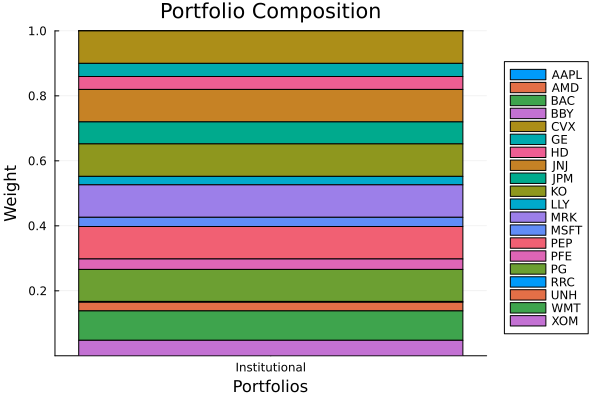

In [5]:
plot_stacked_bar_composition([institutional], rd; xticks = (1:1, ["Institutional"]))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*